# Ecuador Store Sales — Global Forecasting LightGBM

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


plt.style.use("ggplot")
plt.rcParams["font.size"] = 15
COLORS = list(sns.color_palette())

---

# 1. Data Preprocessing

In [ ]:
# helper function to print messages
def cprint(title, *args):
    print(
        "="*len(title), title, "="*len(title),
        *args,
        sep="\n",
    )

### Loading the datasets.

We begin by loading the datasets. We then look at some of their characteristics and perform the necessary changes for visualization and modeling later.

In [ ]:




train = pd.read_csv('../data/train.csv',parse_dates=["date"])
test = pd.read_csv('../data/test.csv',parse_dates=["date"])
oil = pd.read_csv('../data/oil.csv',parse_dates=["date"]).rename(columns={"dcoilwtico": "oil"})


store = pd.read_csv('../data/stores.csv')

transaction = pd.read_csv('../data/transactions.csv',parse_dates=["date"])
holiday = pd.read_csv('../data/holidays_events.csv',parse_dates=["date"])

### Check: There are missing gaps in the training data.

In this problem, our target series for forecasting is the `sales` column for the Ecuadorian-based grocery retailer. With 54 stores present, each having 33 types of products sold, this amounts to 1782 target series for forecasting. We can check that there are missing gaps (4 missing dates) in our target series, which we will investigate next.

In [ ]:
num_family = train.family.nunique()
num_store = train.store_nbr.nunique()
num_ts = train.groupby(["store_nbr", "family"]).ngroups
train_start = train.date.min().date()
train_end = train.date.max().date()
num_train_date = train.date.nunique()
train_len = (train_end - train_start).days + 1
test_start = test.date.min().date()
test_end = test.date.max().date()
num_test_date = test.date.nunique()
test_len = (test_end - test_start).days + 1

In [ ]:
cprint(
    "Basic information of data",
    f"Number of family types      : {num_family}",
    f"Number of stores            : {num_store}",
    f"Number of store-family pairs: {num_family * num_store}",
    f"Number of target series     : {num_ts}",
    "",
    f"Number of unique train dates: {num_train_date}",
    f"Train date range            : {train_len} days from {train_start} to {train_end}",
    f"Number of unique test dates : {num_test_date}",
    f"Test date range             : {test_len} days from {test_start} to {test_end}",
)

Basic information of data
Number of family types      : 33
Number of stores            : 54
Number of store-family pairs: 1782
Number of target series     : 1782

Number of unique train dates: 1684
Train date range            : 1688 days from 2013-01-01 to 2017-08-15
Number of unique test dates : 16
Test date range             : 16 days from 2017-08-16 to 2017-08-31


###  Check: The 4 missing dates fall on Christmas across the years.

It turns out that all the target series have missing dates on Christmas across the years, which suggests that the stores could be closed on this day.

In [ ]:
missing_dates = pd.date_range(train_start, train_end).difference(train.date.unique())
missing_dates = missing_dates.strftime("%Y-%m-%d").tolist()

unique_dp_count = train.groupby(["store_nbr", "family"]).date.count().unique().tolist()

In [ ]:
cprint(
    "Missing gaps in time series",
    f"List incl. unique counts of data points: {unique_dp_count}",
    f"Missing dates                          : {missing_dates}",
)

Missing gaps in time series
List incl. unique counts of data points: [1684]
Missing dates                          : ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


To address this problem, we fill the missing dates by reindexing our training data, and then fill the `sales` and `onpromotion` columns with 0s to indicate that there are no sales/promotions since the stores are closed.

In [ ]:
# reindex training data
multi_idx = pd.MultiIndex.from_product(
    [pd.date_range(train_start, train_end), train.store_nbr.unique(), train.family.unique()],
    names=["date", "store_nbr", "family"],
)
train = train.set_index(["date", "store_nbr", "family"]).reindex(multi_idx).reset_index()

# fill missing values with 0s
train[["sales", "onpromotion"]] = train[["sales", "onpromotion"]].fillna(0.)
train.id = train.id.interpolate(method="linear") # interpolate linearly as a filler for the 'id'

### Check: There are no oil prices on weekends.

We can check there there are no oil prices on weekends, and this is mainly due to the nature of trading markets.

In [ ]:
missing_oil_dates = pd.date_range(train_start, test_end).difference(oil.date)
num_missing_oil_dates = len(missing_oil_dates)
num_wknd_missing = (missing_oil_dates.weekday >= 5).sum()
total_num_wknd = (pd.date_range(train_start, test_end).weekday >= 5).sum()

In [ ]:
cprint(
    "Missing oil dates",
    f"Number of missing oil dates: {num_missing_oil_dates}",
    f"Number of weekends missing : {num_wknd_missing}",
    f"Total number of weekends   : {total_num_wknd}",
)

Missing oil dates
Number of missing oil dates: 486
Number of weekends missing : 486
Total number of weekends   : 486


Because our grocery stores open on weekends as well, there is a need to estimate the missing oil prices if we are to use them in our models. For simplicity, we fill the missing values in the `oil` column using linear interpolation.

In [ ]:
# reindex oil data
oil = oil.merge(
    pd.DataFrame({"date": pd.date_range(train_start, test_end)}),
    on="date",
    how="outer",
).sort_values("date", ignore_index=True)

# fill missing values using linear interpolation
oil.oil = oil.oil.interpolate(method="linear", limit_direction="both")

### Check: There are missing transactions due to either zero sales or missing records.

With 54 stores and 1688 training dates, we should have a total of 91152 records of transaction. However, this does not tally with the dataset given. We can easily check that the transaction data does not record days with zero sales, indicating that such days are generally not recorded. As such, for days with zero sales, we fill the `transactions` column with 0s.

After doing that, we observe that there are still missing values, suggesting that there are indeed missing data entries not due to zero sales. For simplicity, we fill the remaining missing values using linear interpolation.

In [ ]:
num_zero_sales = (train.groupby(["date", "store_nbr"]).sales.sum().eq(0)).sum()
total_rec = num_store * train_len
curr_rec = len(transaction.index)
missing_rec = total_rec - curr_rec - num_zero_sales

In [ ]:
cprint(
    "Missing transaction records",
    f"Correct number of records: {total_rec}",
    "",
    "Breakdown...",
    f"Current number of records: {curr_rec}",
    f"Number of zero sales     : {num_zero_sales}",
    f"Number of missing records: {missing_rec}",
)

Missing transaction records
Correct number of records: 91152

Breakdown...
Current number of records: 83488
Number of zero sales     : 7546
Number of missing records: 118


In [ ]:
# compute total sales for each store
store_sales = train.groupby(["date", "store_nbr"]).sales.sum().reset_index()

# reindex transaction data
transaction = transaction.merge(
    store_sales,
    on=["date", "store_nbr"],
    how="outer",
).sort_values(["date", "store_nbr"], ignore_index=True)

# fill missing values with 0s for days with zero sales
transaction.loc[transaction.sales.eq(0), "transactions"] = 0.
transaction = transaction.drop(columns=["sales"])

# fill remaining missing values using linear interpolation
transaction.transactions = transaction.groupby("store_nbr", group_keys=False).transactions.apply(
    lambda x: x.interpolate(method="linear", limit_direction="both")
)

### Check: Regional holidays correspond to the state level, while local holidays correspond to the city level.

For our holiday data, we note that there are holidays on different scales (national, regional and local). Moreover, regional holidays correspond to the state level, while local holidays correspond to the city level. This can be verified by checking the `locale_name` column, as well as the `city` and `state` columns in the store data.

For national holidays, the `locale_name` always states the country, Ecuador. On the other hand, the values of `locale_name` can also be found in the `state` column for regional holidays. The same goes for local holidays with the `city` column. Because of this, we find out that not all cities have local holidays, and not all states have regional holidays.

In [ ]:
national_locale_name = sorted(holiday[holiday.locale.eq("National")].locale_name.unique().tolist())
regional_locale_name = sorted(holiday[holiday.locale.eq("Regional")].locale_name.unique().tolist())
local_locale_name = sorted(holiday[holiday.locale.eq("Local")].locale_name.unique().tolist())

In [ ]:
cprint(
    "List of locale names for each holiday",
    "Locale names for national holidays:",
    national_locale_name,
    "",
    "Locale names for regional holidays:",
    regional_locale_name,
    "",
    "Locale names for local holidays:",
    local_locale_name,
)

List of locale names for each holiday
Locale names for national holidays:
['Ecuador']

Locale names for regional holidays:
['Cotopaxi', 'Imbabura', 'Santa Elena', 'Santo Domingo de los Tsachilas']

Locale names for local holidays:
['Ambato', 'Cayambe', 'Cuenca', 'El Carmen', 'Esmeraldas', 'Guaranda', 'Guayaquil', 'Ibarra', 'Latacunga', 'Libertad', 'Loja', 'Machala', 'Manta', 'Puyo', 'Quevedo', 'Quito', 'Riobamba', 'Salinas', 'Santo Domingo']


### Check: There are many holidays of a similar nature, which can be grouped together to simplify modeling.

In the holiday data, some days surrounding the actual holidays are also labeled as holidays. An example is shown below for Christmas (Navidad) 2012, where terms like '-4' and '+1' indicate the number of days before and after Christmas. We can check that in general, these surrounding days are labeled as 'Additional' in the `type` column. In addition, since Christmas 2012 falls on a Tuesday, 24 December 2012 is declared as a bridge holiday to make a long weekend. We can group such holidays together for standardization.

In [ ]:
holiday[(holiday.description.str.contains("Navidad"))&(holiday.date.dt.year.eq(2012))]

,date,type,locale,locale_name,description,transferred
31,2012-12-21,Additional,National,Ecuador,Navidad-4,False
33,2012-12-22,Additional,National,Ecuador,Navidad-3,False
34,2012-12-23,Additional,National,Ecuador,Navidad-2,False
35,2012-12-24,Bridge,National,Ecuador,Puente Navidad,False
36,2012-12-24,Additional,National,Ecuador,Navidad-1,False
37,2012-12-25,Holiday,National,Ecuador,Navidad,False
38,2012-12-26,Additional,National,Ecuador,Navidad+1,False


It turns out that there are other examples, such as the Independence Day for the different cities. For simplicity, we assume that such holidays should have similar impacts on the store sales. We assign the same labels for such holidays by removing extra words like bridge (puente) and the city/state names from the `description` column. The function to process the column is given below.

In [ ]:
def process_holiday(s):
    if "futbol" in s:
        return "futbol"
    to_remove = list(set(store.city.str.lower()) | set(store.state.str.lower()))
    for w in to_remove:
        s = s.replace(w, "")
    return s

In [ ]:
holiday.description = holiday.apply(
    lambda x: x.description.lower().replace(x.locale_name.lower(), ""),
    axis=1,
).apply(
    process_holiday
).replace(
    r"[+-]\d+|\b(de|del|traslado|recupero|puente|-)\b", "", regex=True,
).replace(
    r"\s+|-", " ", regex=True,
).str.strip()

holiday.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,fundacion,False
1,2012-04-01,Holiday,Regional,Cotopaxi,provincializacion,False
2,2012-04-12,Holiday,Local,Cuenca,fundacion,False
3,2012-04-14,Holiday,Local,Libertad,cantonizacion,False
4,2012-04-21,Holiday,Local,Riobamba,cantonizacion,False


We further process the holiday data by removing holidays which are transferred. This can be checked using the `transferred` column. Since the holidays are not celebrated during the official date and are more like normal days, we exclude them.

We then separate them into national/regional/local holidays, and Saturdays that are designated as work days. Prefixes `nat_` / `loc_` are set for national/local holidays to better differentiate them during visualization later. For regional holidays, it turns out that we only have `provincialization`, so it is being labeled as such. An example is shown below, where the national holidays are being encoded as dummy variables. The same applies for the other holidays.

In [ ]:
# remove transferred holidays
holiday = holiday[holiday.transferred.eq(False)]

#########################################
### Saturdays designated as work days ###
#########################################
work_days = holiday[holiday.type.eq("Work Day")]
work_days = work_days[["date", "type"]].rename(
    columns={"type": "work_day"}
).reset_index(drop=True)
work_days.work_day = work_days.work_day.notna().astype(int)
# remove work days after extracting above
holiday = holiday[holiday.type!="Work Day"].reset_index(drop=True)

###################################
### local holidays (city level) ###
###################################
local_holidays = holiday[holiday.locale.eq("Local")]
local_holidays = local_holidays[["date", "locale_name", "description"]].rename(
    columns={"locale_name": "city"}
).reset_index(drop=True)
local_holidays = local_holidays[~local_holidays.duplicated()]
local_holidays = pd.get_dummies(local_holidays, columns=["description"], prefix="loc")

#######################################
### regional holidays (state level) ###
#######################################
regional_holidays = holiday[holiday.locale.eq("Regional")]
regional_holidays = regional_holidays[["date", "locale_name", "description"]].rename(
    columns={"locale_name": "state", "description": "provincializacion"}
).reset_index(drop=True)
regional_holidays.provincializacion = regional_holidays.provincializacion.eq("provincializacion").astype(int)

#########################
### national holidays ###
#########################
national_holidays = holiday[holiday.locale.eq("National")]
national_holidays = national_holidays[["date", "description"]].reset_index(drop=True)
national_holidays = national_holidays[~national_holidays.duplicated()]
national_holidays = pd.get_dummies(national_holidays, columns=["description"], prefix="nat")
# different national holidays may fall on the same day
national_holidays = national_holidays.groupby("date").sum().reset_index()
# shorten name for visualization purposes later
national_holidays = national_holidays.rename(columns={"nat_primer grito independencia": "nat_primer grito"})

national_holidays.head()

,date,nat_batalla,nat_black friday,nat_carnaval,nat_cyber monday,nat_dia difuntos,nat_dia la madre,nat_dia trabajo,nat_futbol,nat_independencia,nat_navidad,nat_primer dia ano,nat_primer grito,nat_terremoto,nat_viernes santo
0,2012-08-10,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,2012-10-12,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,2012-11-02,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,2012-11-03,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,2012-12-21,0,0,0,0,0,0,0,0,0,1,0,0,0,0


---

# 2. Data Exploration

After data preprocessing, we can now analyze our data and discover patterns using visualizations. Before we do that, we reshape our data from the long form to the wide form, where each column corresponds to one time series. Either forms can be easier to work with in different situations. An example is shown below for our target series, where the index is the time dimension represented by `date` and the columns are the `sales` for each store-family pair.

In [ ]:
sales_ts = pd.pivot_table(train, values="sales", index="date", columns=["store_nbr", "family"])
tr_ts = pd.pivot_table(transaction, values="transactions", index="date", columns="store_nbr")
promo_ts = pd.pivot_table(train, values="onpromotion", index="date", columns=["store_nbr", "family"])

sales_ts.head()

store_nbr          1                                                 \
family     AUTOMOTIVE BABY CARE BEAUTY BEVERAGES BOOKS BREAD/BAKERY   
date                                                                  
2013-01-01        0.0       0.0    0.0       0.0   0.0        0.000   
2013-01-02        2.0       0.0    2.0    1091.0   0.0      470.652   
2013-01-03        3.0       0.0    0.0     919.0   0.0      310.655   
2013-01-04        3.0       0.0    3.0     953.0   0.0      198.366   
2013-01-05        5.0       0.0    3.0    1160.0   0.0      301.057   

store_nbr                                        ...        54          \
family     CELEBRATION CLEANING  DAIRY     DELI  ... MAGAZINES   MEATS   
date                                             ...                     
2013-01-01         0.0      0.0    0.0    0.000  ...       0.0   0.000   
2013-01-02         0.0   1060.0  579.0  164.069  ...       0.0  73.771   
2013-01-03         0.0    836.0  453.0  151.582  ...       0.0  50.257   
2013-01-04         0.0    827.0  460.0  131.411  ...       0.0  40.223   
2013-01-05         0.0    811.0  464.0  118.613  ...       0.0  43.431   

store_nbr                                                              \
family     PERSONAL CARE PET SUPPLIES PLAYERS AND ELECTRONICS POULTRY   
date                                                                    
2013-01-01           0.0          0.0                     0.0   0.000   
2013-01-02         228.0          0.0                     0.0  15.514   
2013-01-03         156.0          0.0                     0.0   4.313   
2013-01-04         146.0          0.0                     0.0  26.743   
2013-01-05         205.0          0.0                     0.0  31.118   

store_nbr                                                             
family     PREPARED FOODS PRODUCE SCHOOL AND OFFICE SUPPLIES SEAFOOD  
date                                                                  
2013-01-01            0.0     0.0                        0.0     0.0  
2013-01-02           61.0     0.0                        0.0     3.0  
2013-01-03            1.0     0.0                        0.0     2.0  
2013-01-04           38.0     0.0                        0.0     2.0  
2013-01-05           32.0     0.0                        0.0     1.0  

[5 rows x 1782 columns]

For visualization purposes, there is a need to scale our data if we want to look at the average value of the `sales` column. This helps to balance the impact across all store-family pairs on the average value. The same applies for the `transactions` and `onpromotion` values, but we will scale them only when needed later.

We also convert back the scaled sales data to the long form and add the holiday columns to analyze the holiday effects later. An additional column `no_holiday` is computed to indicate days without any holidays. This is important when we are comparing the store sales between holiday and non-holiday periods.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# scale target series
scaler = MinMaxScaler()
sales_ts_scaled = sales_ts.copy()
sales_ts_scaled[sales_ts_scaled.columns] = scaler.fit_transform(sales_ts_scaled)

# convert back to long form and add the holiday columns
holiday_sales_merged = sales_ts_scaled.melt(
    value_name="sales", ignore_index=False,
).reset_index().merge(
    store, on="store_nbr", how="left",
).merge(
    work_days, on="date", how="left",
).merge(
    local_holidays, on=["date", "city"], how="left",
).merge(
    regional_holidays, on=["date", "state"], how="left",
).merge(
    national_holidays, on="date", how="left",
).fillna(0)

# include dummy variable for dates without any holidays
holiday_list = [col for col in holiday_sales_merged if col.startswith(("loc_", "nat_", "provincializacion"))]
holiday_sales_merged["no_holiday"] = holiday_sales_merged[holiday_list].sum(axis=1).eq(0).astype(int)

holiday_sales_merged.head()

,date,store_nbr,family,sales,city,state,type,cluster,work_day,loc_cantonizacion,...,nat_dia la madre,nat_dia trabajo,nat_futbol,nat_independencia,nat_navidad,nat_primer dia ano,nat_primer grito,nat_terremoto,nat_viernes santo,no_holiday
0,2013-01-01,1,AUTOMOTIVE,0.000000,Quito,Pichincha,D,13,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
1,2013-01-02,1,AUTOMOTIVE,0.105263,Quito,Pichincha,D,13,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2013-01-03,1,AUTOMOTIVE,0.157895,Quito,Pichincha,D,13,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,2013-01-04,1,AUTOMOTIVE,0.157895,Quito,Pichincha,D,13,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,2013-01-05,1,AUTOMOTIVE,0.263158,Quito,Pichincha,D,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### Finding: In general, the number of zero sales is decreasing over time. Besides Christmas, there are also large numbers of zero sales on New Year's Day.

We start off by counting the number of target series with zero sales for each day. The counts of zero sales has a general **downward trend**, suggesting that periods with no sales are becoming less frequent and that the stores are generating positive sales consistently. This could be due to changes in some covariates that have a **temporal relationship** with the sales numbers, which we will investigate later.

Besides Christmas, we also have large counts of zero sales on New Year's Day across the years. Similarly, many stores could be closed on this occasion, which we should take note of in our models later. Interestingly, there are great fluctations in the count of zero sales between 2014 and 2015.

### Finding: There are some target series with all values equal to zero.

Our training data has 53 target series with all values equal to zero. This could be due to poor sales performance or product unavailability. What is interesting here is that all stores have about 0 to 3 zero constant target series. If we consider this by the product family, books have the most number of zero constant target series. It appears that the **problem of zero sales could be due to the type of product** being sold.

### Finding: There are many target series with leading zeros.

We look at some possible patterns of zero store sales. The zero constant target series are removed to get a better picture of the remaining target series. It turns out that we have many target series with leading zeros, with some series consisting of thousands of leading zeros. This suggests the possibility of product unavailability, or simply poor sales performance at the start.

We note that the distribution of leading zeros is **fairly consistent** across the stores, with only a few stores having the boxplots lying above the rest. Examples are store numbers 52, 53. This could mean that some stores are more recently open, so there are no sales at the start of the target series.

On the other hand, the distribution of leading zeros **varies** across the families of products. This suggests that the **problem of leading zeros could be related to the type of products**, like the target series for books all having thousands of leading zeros. This supports the previous finding above.

### Finding: There are few target series with trailing zeros.

We can also examine the number of trailing zeros at the end of the target series. Similarly, we remove the zero constant target series here. There are not as many target series with trailing zeros, suggesting **consistent** sales across the years.

However, the presence of target series having hundreds of trailing zeros could be due to poor sales performance or that the product is no longer available towards the end. An example would be lawn and garden. In this case, **generating zero forecasts** for such target series would be a reasonable approach.

### Finding: The average sales is correlated with oil prices, promotions, and store transactions.

After analyzing the target series, we look at possible covariates to help improve our models. The `transactions` column is considered as a past covariate because only its past values are known at the point of forecasting. To forecast the sales for tomorrow, we only know the values of the transactions that happened up to today.

On the other hand, the `oil` and `onpromotion` columns are future covariates because their current (and possibly future) values are known at the point of forecasting. To forecast the sales for tomorrow, we have the values of oil prices and promotion values for tomorrow. This makes sense because setting the promotion values is usually done in advance to promote future store sales. It is unusual for us to know the oil prices in advance, but since we are given the data, one possible explanation is that we are using estimates of the oil prices.

As mentioned previously, the `transactions` and `onpromotion` columns will be scaled before computing the average values. The average sales are computed by taking the average across all 1782 target series. From the plots below, we observe that:
* Oil prices are **negatively** correlated with average sales. With Ecuador being an oil-dependent country, larger oil prices could have inflationary effects, resulting in smaller store sales.
* Promotion values are **positively** correlated with average sales. This is straightfoward because with more ongoing promotions, this attracts human traffic and thus encourages greater sales. Another interesting observation is that there are **zero promotion values up to early 2014**.
* Store transactions are **positively** correlated with average sales. The grocery stores consist of many product families which complement each other, like poultry, produce, and other food products. It makes sense that if a person buys some meat, that person is also more likely to buy vegetables as a complement for a balanced diet. As such, the sales for one product could affect another, so stores with larger transactions should also have larger sales for each product family in general.
* The average sales has a general **upward trend**, with sharp declines during Christmas and New Year as explained earlier. With smaller oil prices, greater promotion values and larger store transactions, these seem to support the correlation with average sales as explained above.

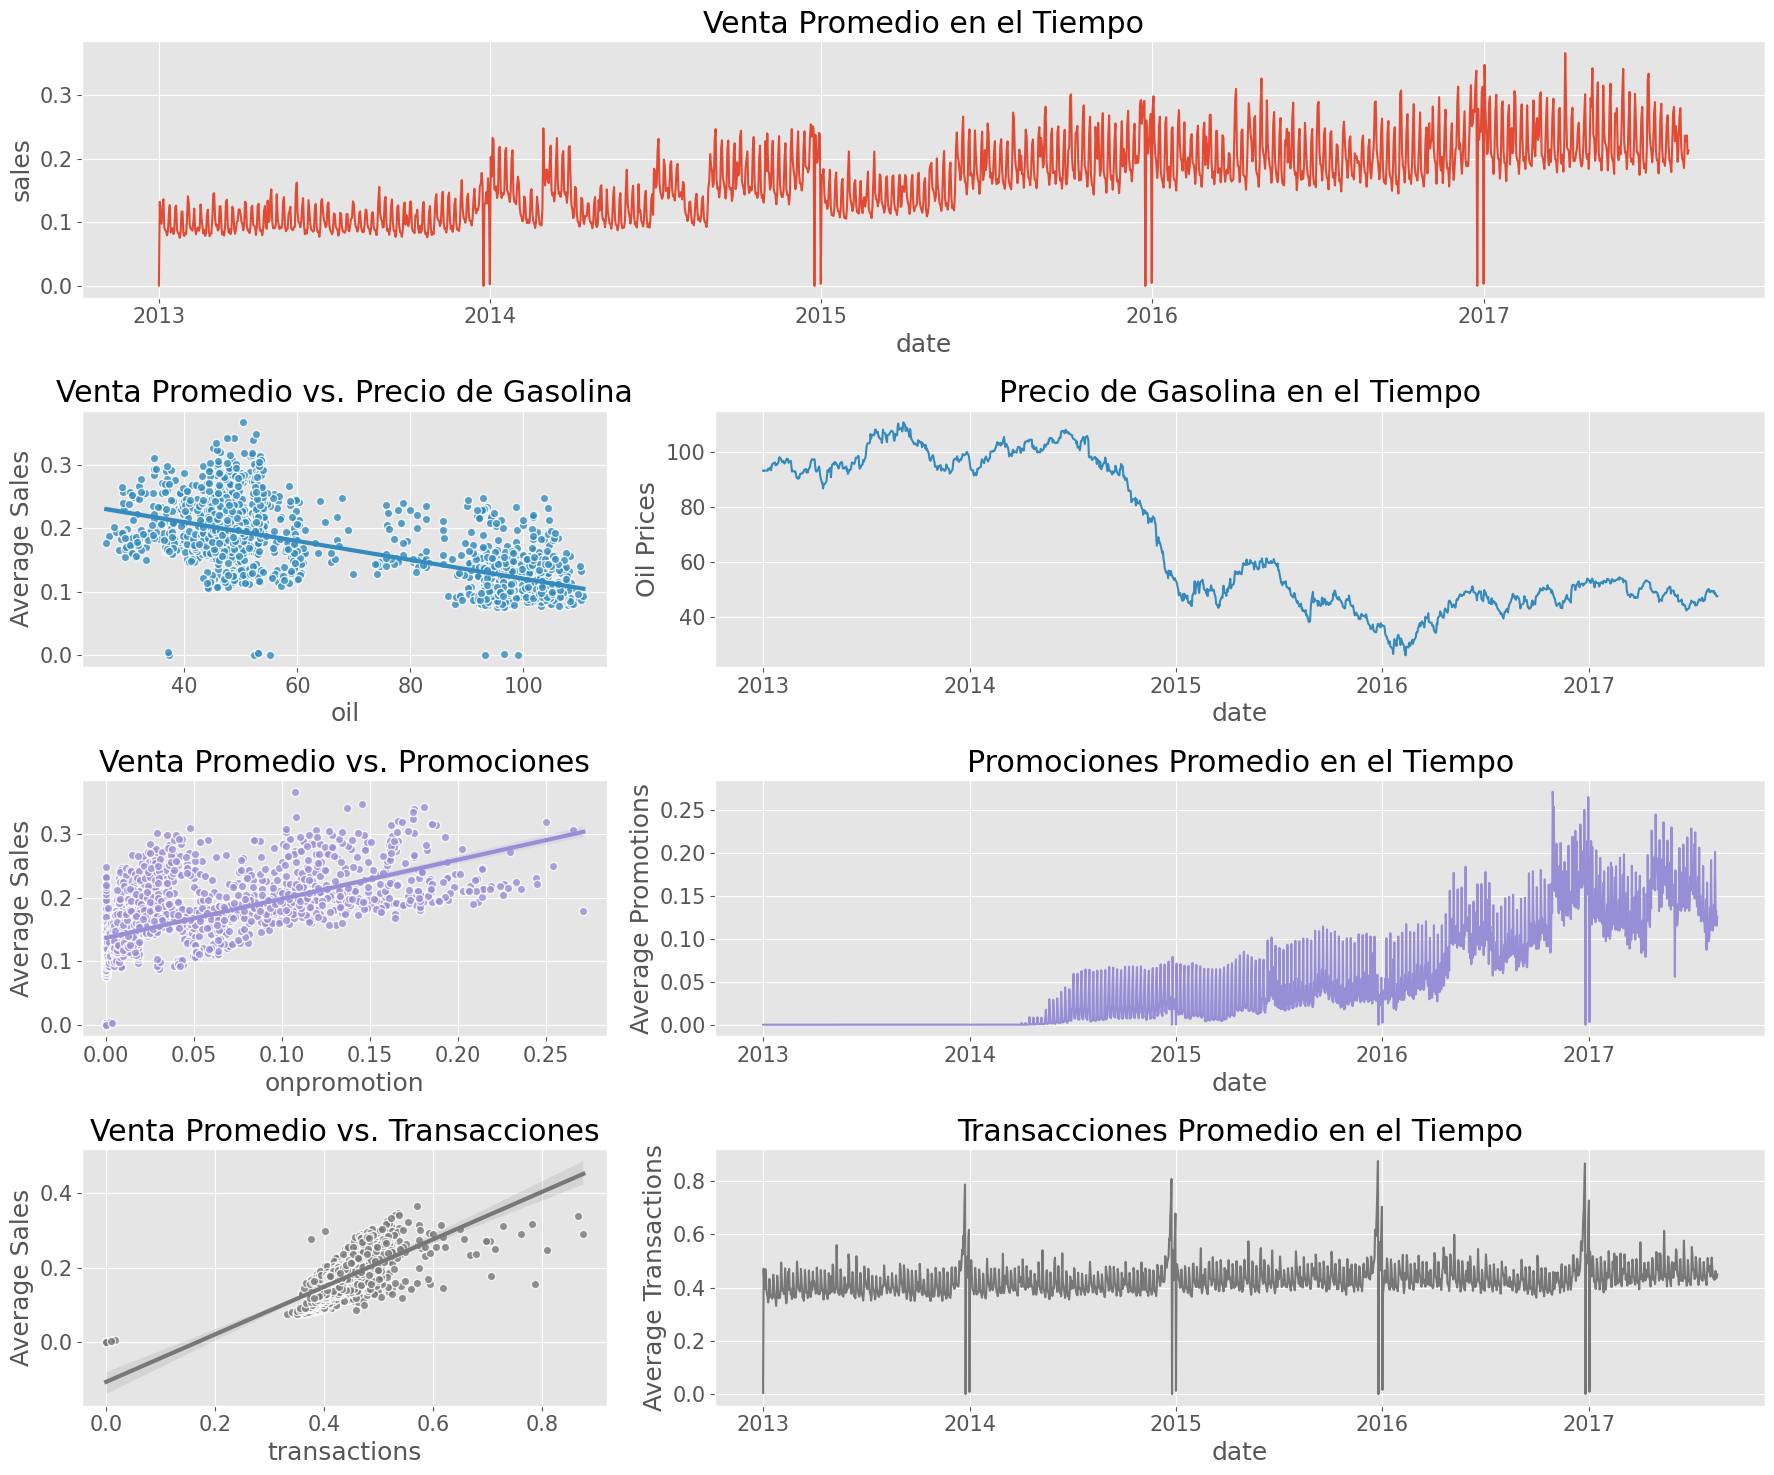

In [ ]:
def plot_sales_correlation():
    tr_ts_scaled = tr_ts.copy()
    tr_ts_scaled[tr_ts_scaled.columns] = scaler.fit_transform(tr_ts_scaled)

    promo_ts_scaled = promo_ts.copy()
    promo_ts_scaled[promo_ts_scaled.columns] = scaler.fit_transform(promo_ts_scaled)

    mean_sales_ts_scaled = sales_ts_scaled.mean(axis=1).to_frame("sales").reset_index()
    mean_promo_ts_scaled = promo_ts_scaled.mean(axis=1).to_frame("onpromotion").reset_index()
    mean_tr_ts_scaled = tr_ts_scaled.mean(axis=1).to_frame("transactions").reset_index()


    plot_kwargs = {
        "scatter_kws": {"edgecolor": "white"},
        "line_kws": {"lw": 3},
    }

    fig = plt.figure(figsize=(18, 15))
    gs = fig.add_gridspec(4, 2, width_ratios=(1, 2))

    sns.lineplot(
        data=mean_sales_ts_scaled,
        x="date",
        y="sales",
        ax=fig.add_subplot(gs[0, :]),
    )
    plt.title("Venta Promedio en el Tiempo")

    sns.regplot(
        x=oil.oil.iloc[:train_len], y=mean_sales_ts_scaled.sales,
        ax=fig.add_subplot(gs[1, 0]),
        color=COLORS[1],
        **plot_kwargs,
    )
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio vs. Precio de Gasolina")

    sns.lineplot(
        data=oil.iloc[:train_len, :], x="date", y="oil",
        ax=fig.add_subplot(gs[1, 1]),
        color=COLORS[1],
    )
    plt.ylabel("Oil Prices")
    plt.title("Precio de Gasolina en el Tiempo")

    sns.regplot(
        x=mean_promo_ts_scaled.onpromotion, y=mean_sales_ts_scaled.sales,
        ax=fig.add_subplot(gs[2, 0]),
        color=COLORS[2],
        **plot_kwargs,
    )
    plt.xlabel("onpromotion")
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio vs. Promociones")

    sns.lineplot(
        data=mean_promo_ts_scaled, x="date", y="onpromotion",
        ax=fig.add_subplot(gs[2, 1]),
        color=COLORS[2],
    )
    plt.ylabel("Average Promotions")
    plt.title("Promociones Promedio en el Tiempo")

    sns.regplot(
        x=mean_tr_ts_scaled.transactions, y=mean_sales_ts_scaled.sales,
        ax=fig.add_subplot(gs[3, 0]),
        color=COLORS[3],
        **plot_kwargs,
    )
    plt.xlabel("transactions")
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio vs. Transacciones")

    sns.lineplot(
        data=mean_tr_ts_scaled, x="date", y="transactions",
        ax=fig.add_subplot(gs[3, 1]),
        color=COLORS[3],
    )
    plt.ylabel("Average Transactions")
    plt.title("Transacciones Promedio en el Tiempo")

    plt.tight_layout()
    plt.show()

plot_sales_correlation()

### Finding: Some national holidays/events like Labor Day, Christmas, and the 2016 earthquake have larger impacts on sales.

Holidays/events are future covariates because the dates are usually known in advance. For simplicity, we will just use the term 'holiday' to denote both holidays and events throughout this notebook. As mentioned earlier, we need to compare sales between holiday and non-holiday periods. Looking at the boxplots below for each holiday, we note that **some have larger impacts on sales**. Examples are Labor Day (dia trabago), Christmas (navidad), and the 2016 earthquake (terremoto). We need to select the more useful ones to include in our models later.

/tmp/ipykernel_165/1055156067.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_165/1055156067.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_165/1055156067.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_165/1055156067.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_165/1055156067.py:43: FutureWarning: 

Passin

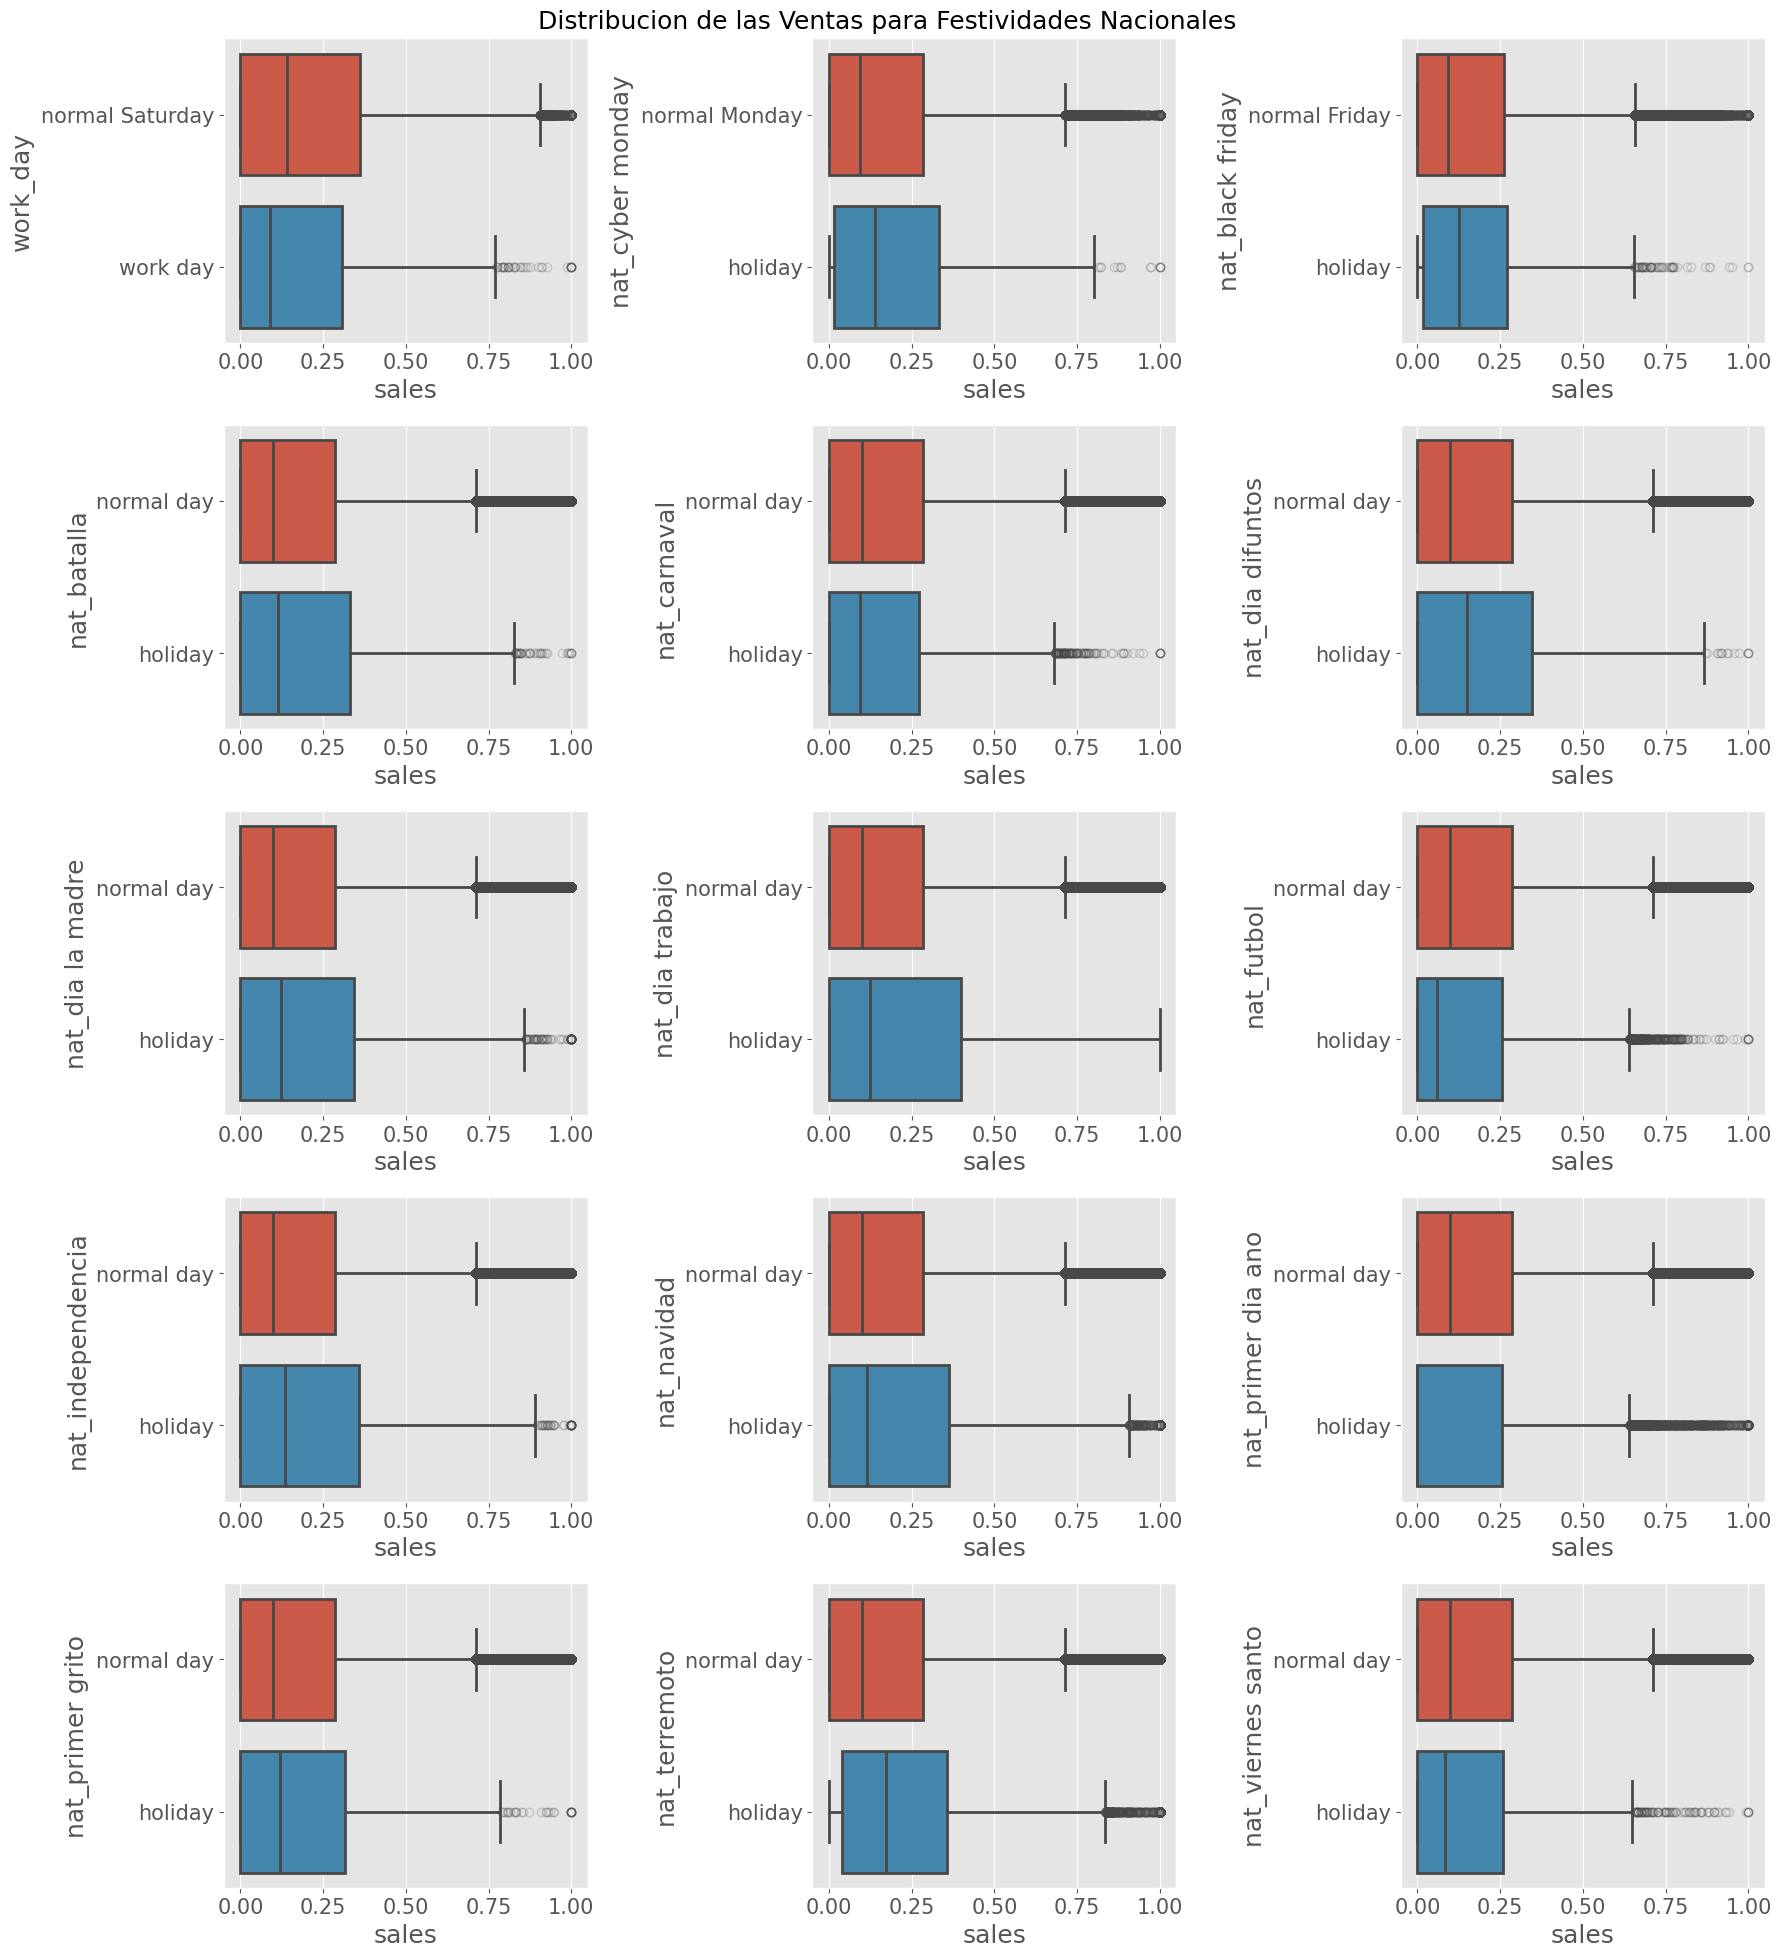

In [ ]:
def plot_national_holiday_distribution():
    df = holiday_sales_merged.copy()
    holiday_list = national_holidays.columns[1:]


    plot_kwargs = {
        "palette": COLORS[:2],
        "linewidth": 2,
        "flierprops": {"alpha": 0.2},
        "orient": "h",
    }

    fig = plt.figure(figsize=(18, 20))

    sns.boxplot(
        data=df[(df.date.dt.weekday.eq(5)) & (df.no_holiday.eq(1))],
        y="work_day",
        x="sales",
        ax=fig.add_subplot(531),
        **plot_kwargs,
    )
    plt.yticks([0, 1], ["normal Saturday", "work day"])

    sns.boxplot(
        data=df[(df.date.dt.weekday.eq(0))],
        y="nat_cyber monday",
        x="sales",
        ax=fig.add_subplot(532),
        **plot_kwargs,
    )
    plt.yticks([0, 1], ["normal Monday", "holiday"])

    sns.boxplot(
        data=df[(df.date.dt.weekday.eq(4))],
        y="nat_black friday",
        x="sales",
        ax=fig.add_subplot(533),
        **plot_kwargs,
    )
    plt.yticks([0, 1], ["normal Friday", "holiday"])

    for j, hol in enumerate(holiday_list.drop(["nat_cyber monday", "nat_black friday"])):
        sns.boxplot(
            data=df[(df[hol].eq(1)) | (df.no_holiday.eq(1))],
            y=hol,
            x="sales",
            ax=fig.add_subplot(5, 3, j+4),
            **plot_kwargs,
        )
        plt.yticks([0, 1], ["normal day", "holiday"])

    plt.suptitle("Distribucion de las Ventas para Festividades Nacionales")
    plt.tight_layout()
    plt.show()

plot_national_holiday_distribution()

### Finding: Regional and local holidays have smaller impacts on sales compared to national holidays.

Similarly, we investigate the effects of regional and local holidays using the boxplots below. Most boxplots look rather similar between the holiday and non-holiday periods, suggesting that regional and local holidays do not have as large of an impact on sales. This is reasonable because **national holidays are of a higher level of significance** and are thus more widely celebrated.

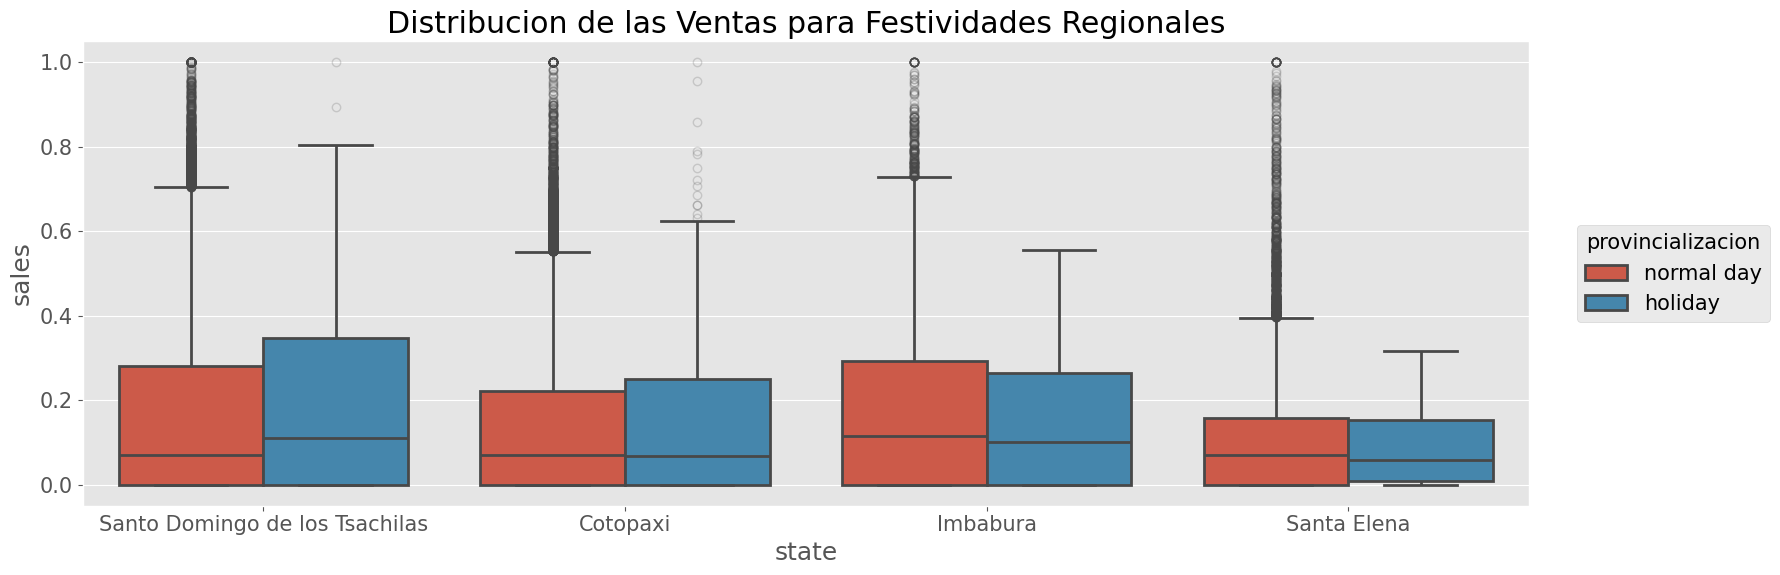

In [ ]:
def plot_regional_holiday_distribution():
    df = holiday_sales_merged.copy()
    states_with_regional_holiday = regional_holidays.state.unique()
    df = df[df.state.isin(states_with_regional_holiday)]


    fig = plt.figure(figsize=(18, 6))

    sns.boxplot(
        data=df[(df.provincializacion.eq(1)) | (df.no_holiday.eq(1))],
        x="state",
        y="sales",
        hue="provincializacion",
        palette=COLORS[:2],
        linewidth=2,
        flierprops={"alpha": 0.2},
        ax=fig.add_subplot(111),
    )
    plt.title("Distribucion de las Ventas para Festividades Regionales")
    leg = plt.legend(loc="center", title="provincializacion", bbox_to_anchor=(1.1, 0.5))
    leg.texts[0].set_text("normal day")
    leg.texts[1].set_text("holiday")

    plt.tight_layout()
    plt.show()

plot_regional_holiday_distribution()

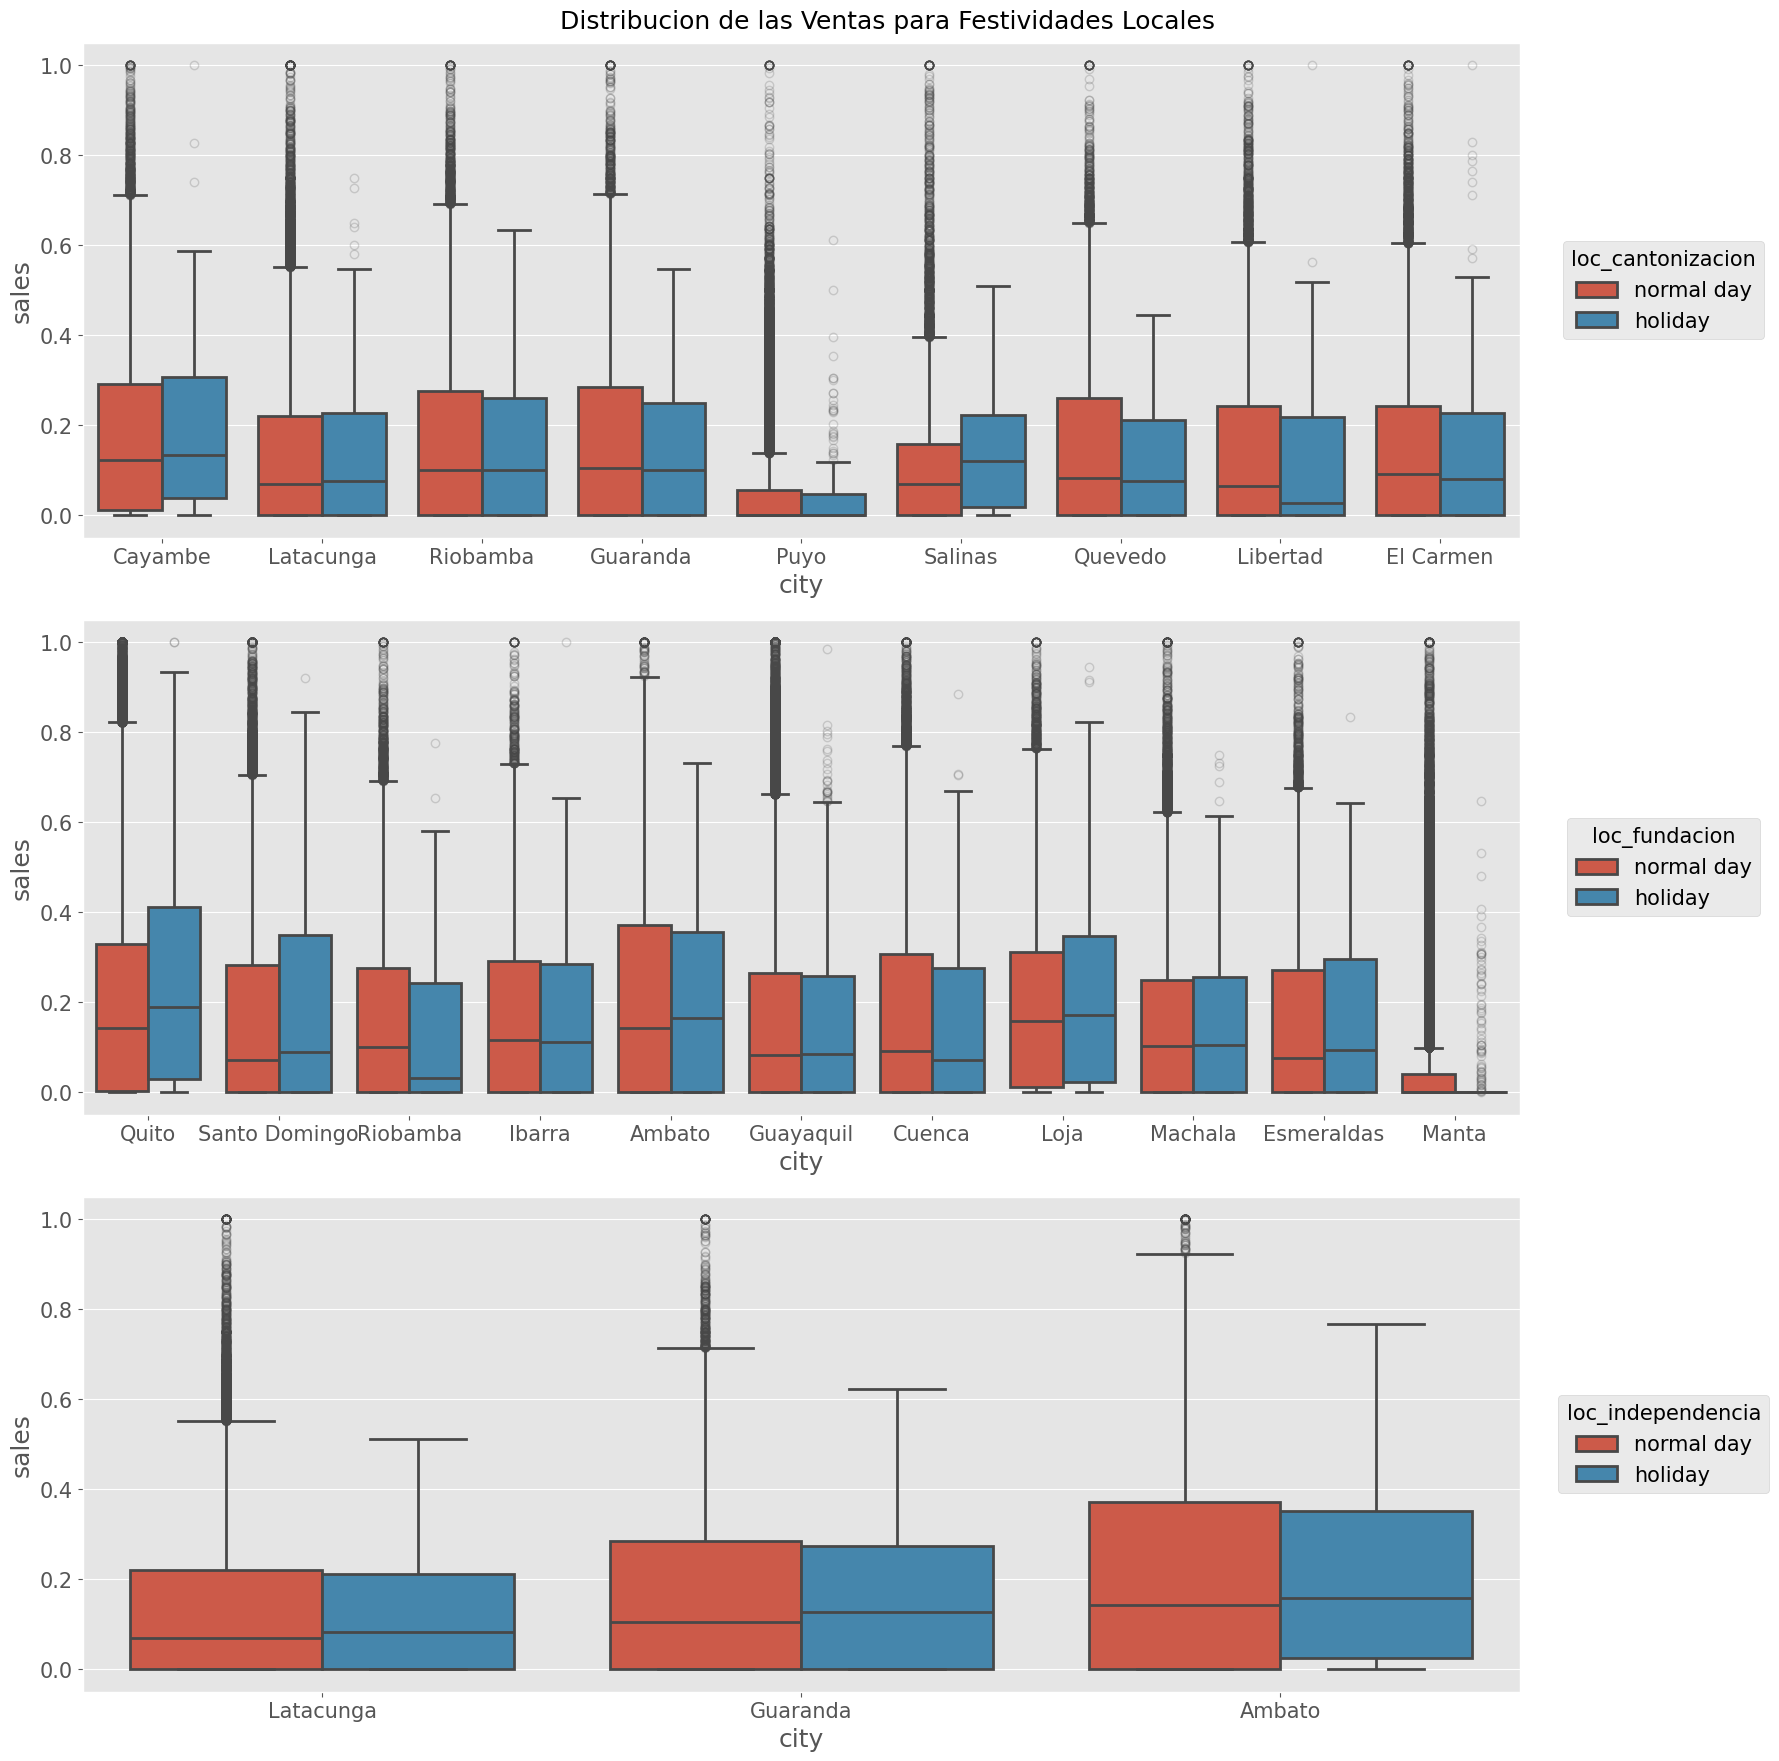

In [ ]:
def plot_local_holiday_distribution():
    df = holiday_sales_merged.copy()
    holiday_list = local_holidays.columns[2:]



    fig = plt.figure(figsize=(18, 18))

    for j, hol in enumerate(holiday_list):
        tmp = df[df.city.isin(local_holidays[local_holidays[hol].eq(1)].city.unique())]
        sns.boxplot(
            data=tmp[(tmp[hol].eq(1)) | (tmp.no_holiday.eq(1))],
            x="city",
            y="sales",
            hue=hol,
            palette=COLORS[:2],
            linewidth=2,
            flierprops={"alpha": 0.2},
            ax=fig.add_subplot(3, 1, j+1),
        )
        leg = plt.legend(loc="center", title=hol, bbox_to_anchor=(1.1, 0.5))
        leg.texts[0].set_text("normal day")
        leg.texts[1].set_text("holiday")

    plt.suptitle("Distribucion de las Ventas para Festividades Locales")
    plt.tight_layout()
    plt.show()

plot_local_holiday_distribution()

### Finding: Sales patterns can be captured by date-related features.

Date-related features like the month and year of each data point are considered future covariates because they are fixed and thus known in advance. To prevent the influence of holiday effects, we make sure to filter the data to only include non-holiday periods. We attempt to look at the distribution of sales for each covariate using boxplots. Some covariates like the days of the year have really large numbers of categories (365-366 days in a year), so inspecting that many boxplots may not be plausible. For such cases, we just compute the average sales (across all the target series) for each time period. The following date-related features are created:
* `day`. With **paydays** being on the 15th and the last day of the month, we see that the sales tend to vary more around the same periods. In particular, this is more noticeable at the end/start of the month.
* `month`. While most of the boxplots look the same, the sales tend to vary greatly in December. This could be a **seasonal pattern** in which people prepare early for Christmas or New Year's Day.
* `year`. It is clear from the boxplots that the sales have a general **upward trend** across the year.
* `day_of_week`. Sales tend to be greater on weekends, which are non-working days for most people. It is reasonable to say that they have more time to visit the grocery stores, which translates to greater sales.
* `day_of_year` / `week_of_year`. The days of the year and weeks of the year give similar information to the months, but at **different levels of granularity**. To illustrate, while sales in the first week tend to be large, sales for the first day of the year is very small.
* `date_index`. The date index (index of the target series) gives similar information to the years, but at a **higher level of granularity**. There are some greater fluctuations in the first half of the time period.

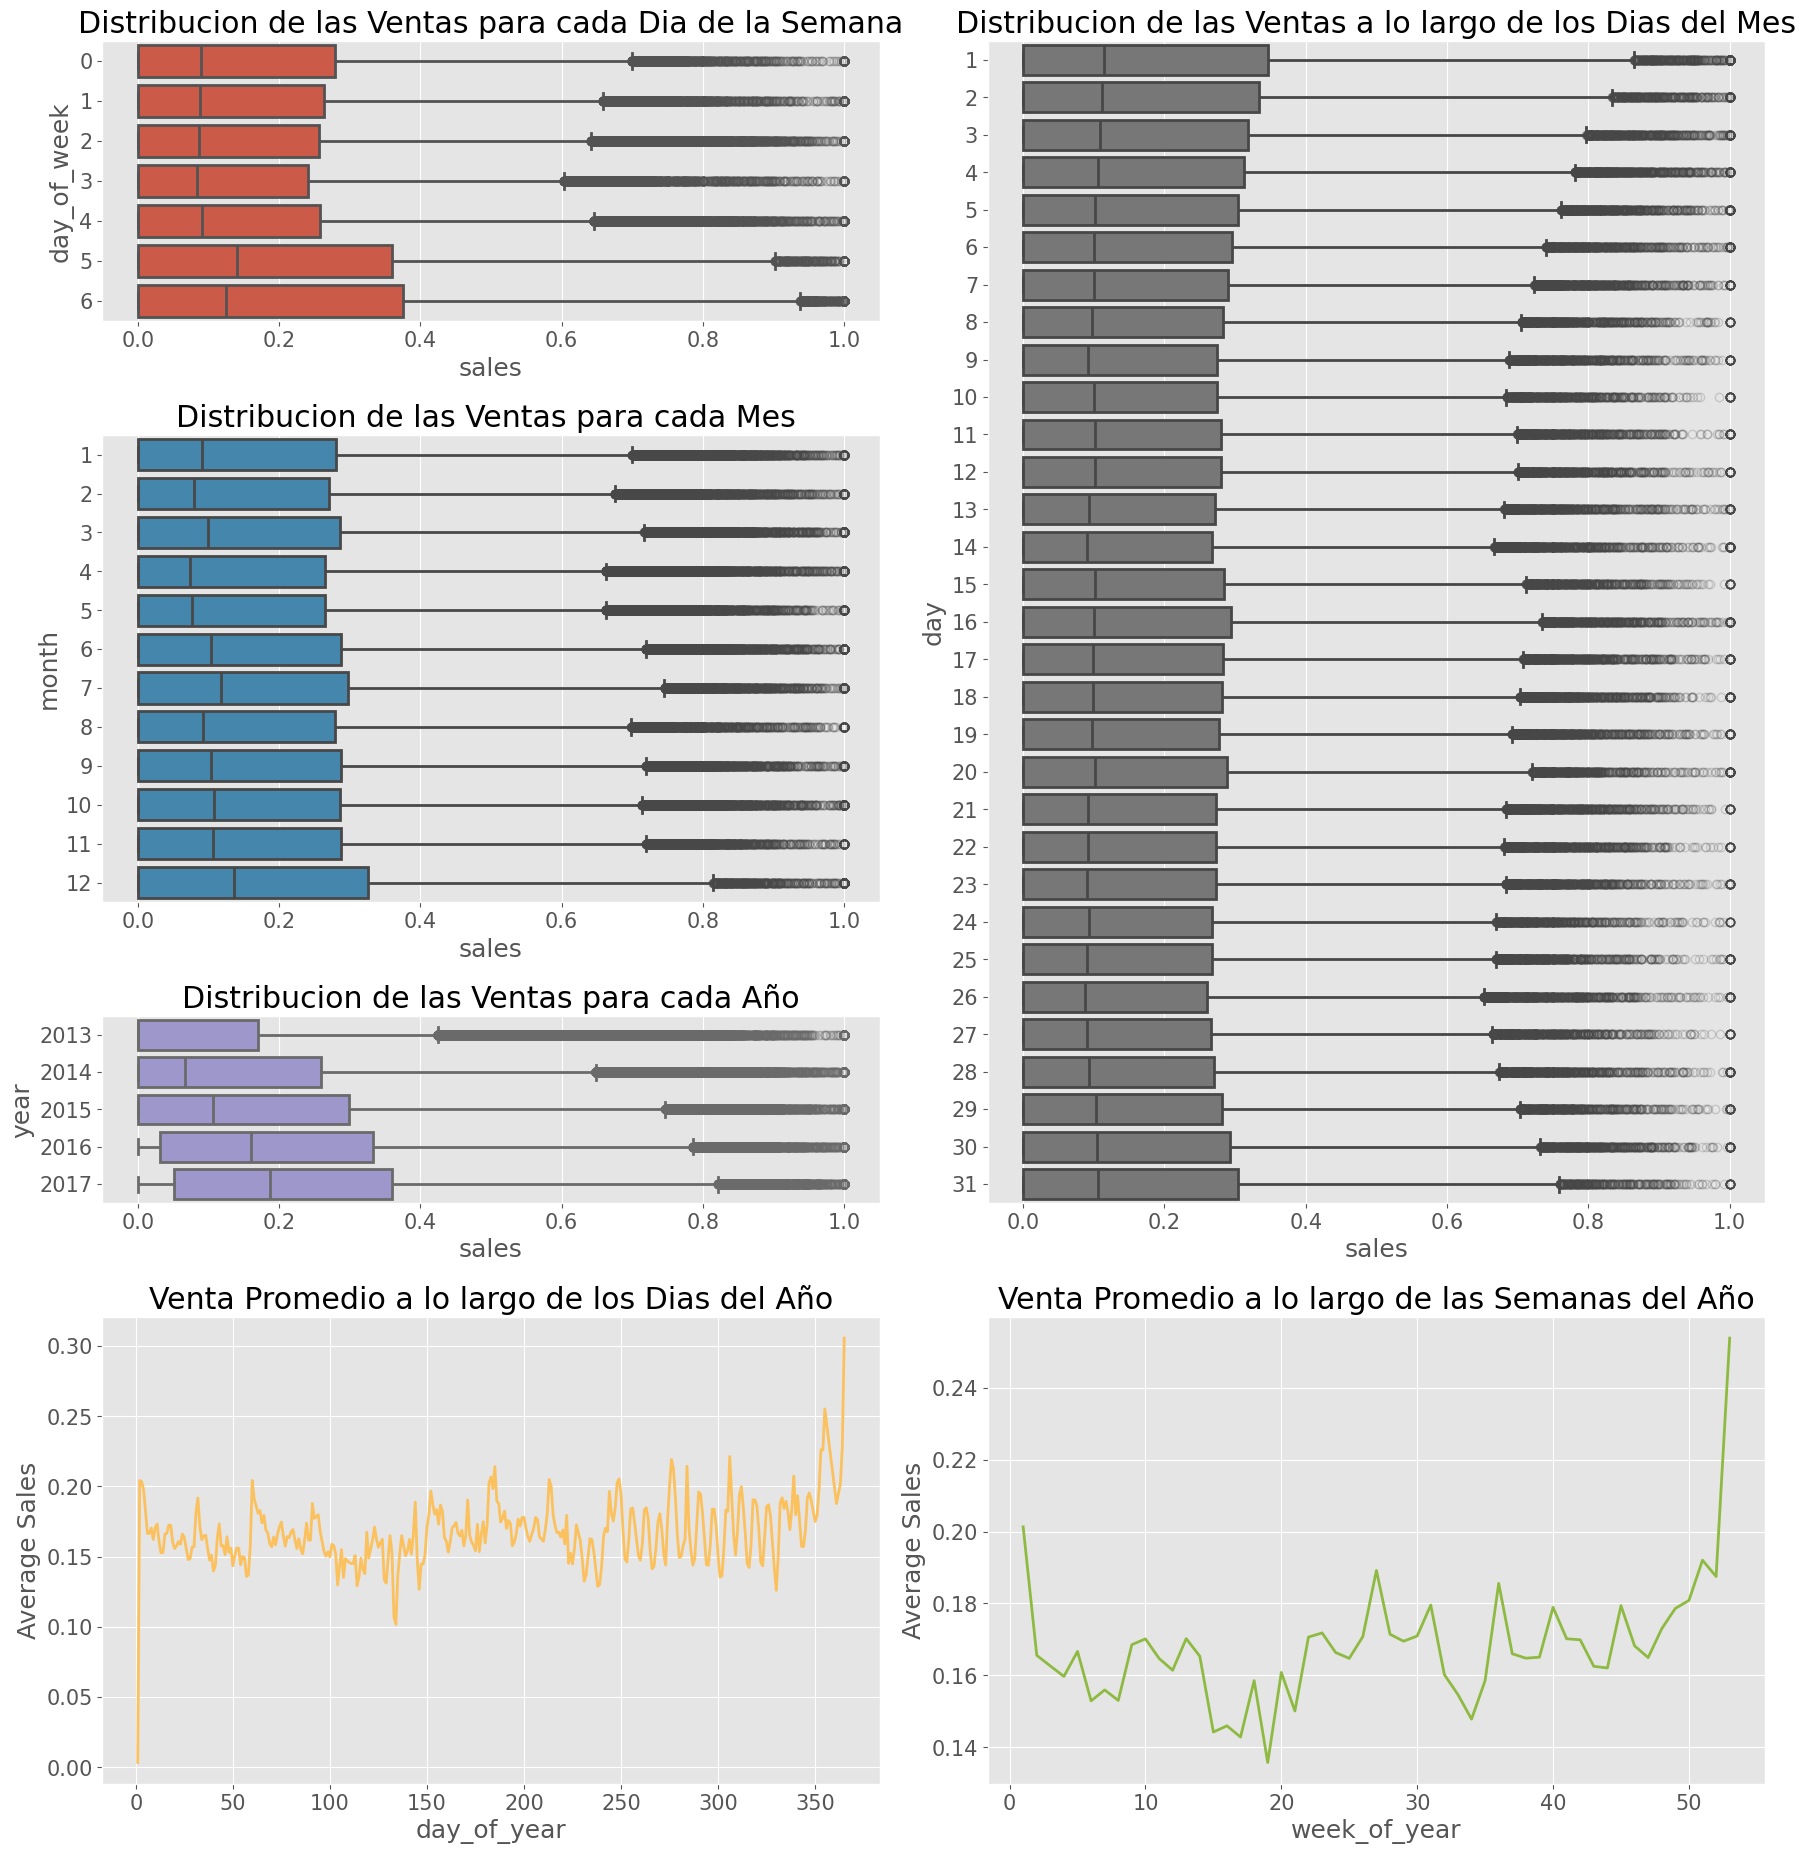

In [ ]:
def plot_date_distribution():
    df = holiday_sales_merged.copy().sort_values(["date", "store_nbr", "family"], ignore_index=True)
    df = df[df.no_holiday.eq(1)].reset_index(drop=True)
    df["day"] = df.date.dt.day
    df["month"] = df.date.dt.month
    df["year"] = df.date.dt.year
    df["day_of_week"] = df.date.dt.dayofweek
    df["day_of_year"] = df.date.dt.dayofyear
    df["week_of_year"] = df.date.dt.isocalendar().week.astype(int)
    df["date_index"] = df.date.factorize()[0]


    plot_kwargs = {
        "linewidth": 2,
        "flierprops": {"alpha": 0.2},
        "orient": "h",
    }

    fig = plt.figure(figsize=(18, 24))
    gs = fig.add_gridspec(5, 2, height_ratios=(3, 5, 2, 5, 5))

    sns.boxplot(
        data=df,
        y="day_of_week",
        x="sales",
        color=COLORS[0],
        ax=fig.add_subplot(gs[0, 0]),
        **plot_kwargs,
    )
    plt.title("Distribucion de las Ventas para cada Dia de la Semana")

    sns.boxplot(
        data=df,
        y="month",
        x="sales",
        color=COLORS[1],
        ax=fig.add_subplot(gs[1, 0]),
        **plot_kwargs,
    )
    plt.title("Distribucion de las Ventas para cada Mes ")

    sns.boxplot(
        data=df,
        y="year",
        x="sales",
        color=COLORS[2],
        ax=fig.add_subplot(gs[2, 0]),
        **plot_kwargs,
    )
    plt.title("Distribucion de las Ventas para cada Año")

    sns.boxplot(
        data=df,
        y="day",
        x="sales",
        color=COLORS[3],
        ax=fig.add_subplot(gs[:3, 1]),
        **plot_kwargs,
    )
    plt.title("Distribucion de las Ventas a lo largo de los Dias del Mes")

    sns.lineplot(
        data=df.groupby("day_of_year").sales.mean().reset_index(),
        x="day_of_year",
        y="sales",
        color=COLORS[4],
        ax=fig.add_subplot(gs[3, 0]),
        linewidth=2,
    )
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio a lo largo de los Dias del Año")

    sns.lineplot(
        data=df.groupby("week_of_year").sales.mean().reset_index(),
        x="week_of_year",
        y="sales",
        color=COLORS[5],
        ax=fig.add_subplot(gs[3, 1]),
        linewidth=2,
    )
    plt.ylabel("Average Sales")
    plt.title("Venta Promedio a lo largo de las Semanas del Año")

    plt.tight_layout()
    plt.show()

plot_date_distribution()